# Baseline Evaluation 

Model without the fixed encoder only the statistical features per window: mean, max, std of the 10 numerical features.

In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt 
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, f1_score 
from sklearn.metrics import ConfusionMatrixDisplay
CLASS_NAMES = ["DoS", "Spoofing", "Fuzzing", "Replay"]
DATA_DIR = Path("embeddings")
DATA_DIR.mkdir(parents=True, exist_ok=True)


## XGBoost

In [2]:
X_train = np.load(DATA_DIR / "X_train_baseline.npy")
y_train = np.load(DATA_DIR/ "y_train_baseline.npy")
X_test = np.load(DATA_DIR / "X_test_baseline.npy")
y_test = np.load(DATA_DIR / "y_test_baseline.npy")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (235430, 30)
y_train: (235430,)
X_test: (100840, 30)
y_test: (100840,)


In [3]:
xgb_model = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    tree_method="hist",
    max_depth=4,
    learning_rate=0.1,
    n_estimators=300,
    n_jobs=4,
    random_state=42
)


In [4]:
xgb_model.fit(X_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'mlogloss'


In [5]:
y_pred = xgb_model.predict(X_test)

print("Predictions:", y_pred.shape)
print("Predicted classes:", np.unique(y_pred))

Predictions: (100840,)
Predicted classes: [0 1 2 3]


### Metrics

- Overall accuracy 
- Precision / Recall / F1 class
- Macro F1 
- Confusion matrix 


In [6]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Balanced_accuracy: {balanced_accuracy_score(y_test, y_pred)}")

Accuracy: 0.8131
Accuracy: 81.31%
Balanced_accuracy: 0.7966712418503766


In [7]:
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))


              precision    recall  f1-score   support

         DoS       0.80      0.93      0.86     26414
    Spoofing       0.82      0.54      0.65     18918
     Fuzzing       0.94      0.83      0.88     36205
      Replay       0.66      0.89      0.76     19303

    accuracy                           0.81    100840
   macro avg       0.81      0.80      0.79    100840
weighted avg       0.83      0.81      0.81    100840

Macro F1: 0.7884930178239684


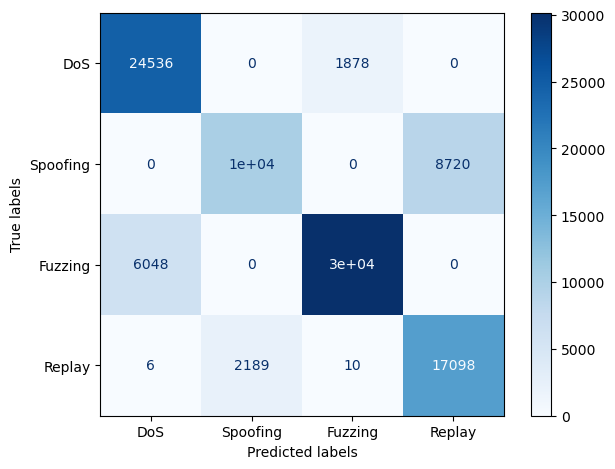

In [8]:
cm = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)

display.plot(cmap="Blues", colorbar=True)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.tight_layout()
plt.show()
